# ARIMA — AutoRegressive Integrated Moving Average

## 1. What is ARIMA?

**ARIMA** stands for:

> **AutoRegressive Integrated Moving Average**

ARIMA is one of the most commonly used classical models for **time-series forecasting**.

It is represented as:

$$
\boxed{\text{ARIMA}(p,d,q)}
$$

where:

* $p$ = AutoRegressive order
* $d$ = Degree of differencing
* $q$ = Moving Average order

The three components are:

$$
\boxed{\text{ARIMA} = \text{AR} + \text{I} + \text{MA}}
$$

---

# 2. Components of ARIMA

ARIMA consists of three components:

1. **AR — AutoRegressive**
2. **I — Integrated**
3. **MA — Moving Average**

The basic idea is:

```text
Original Time Series
        ↓
   Differencing
        ↓
Stationary Series
        ↓
    AR + MA
        ↓
     ARIMA
```

---

# 3. AR — AutoRegressive

The **AutoRegressive (AR)** component assumes that the current value depends on its own previous values.

## AR(1)

For an AR(1) model:

$$
\boxed{
Y_t = c + \phi_1Y_{t-1} + \epsilon_t
}
$$

where:

* $Y_t$ = current value
* $Y_{t-1}$ = previous value
* $c$ = constant/intercept
* $\phi_1$ = AR coefficient
* $\epsilon_t$ = random error at time $t$

For AR($p$):

$$
\boxed{
Y_t =
c +
\phi_1Y_{t-1}
+\phi_2Y_{t-2}
+\cdots
+\phi_pY_{t-p}
+\epsilon_t
}
$$

Therefore:

$$
\boxed{
p = \text{number of AR lags}
}
$$

### Intuition

AR uses **past observations** to predict the current observation.

```text
Y(t-3) ──→ Y(t-2) ──→ Y(t-1) ──→ Y(t)
```

For example, an AR(2) model uses:

```text
Y(t-1)
Y(t-2)
```

to predict $Y_t$.

---

# 4. I — Integrated

The **Integrated (I)** component refers to **differencing** the time series.

Differencing is used to remove trends and make a non-stationary series approximately stationary.

## First-Order Differencing

The first difference is:

$$
\boxed{
\Delta Y_t = Y_t - Y_{t-1}
}
$$

For example:

```text
Original series:

100   110   120   135   150

First difference:

       10    10    15    15
```

The parameter $d$ represents the number of times the series is differenced.

$$
\boxed{
d = \text{number of differencing operations}
}
$$

---

## Second-Order Differencing

If first-order differencing is not sufficient, we can difference the series again.

$$
\Delta^2Y_t
===========

\Delta Y_t-\Delta Y_{t-1}
$$

Expanding this:

$$
\boxed{
\Delta^2Y_t
===========

Y_t-2Y_{t-1}+Y_{t-2}
}
$$

Usually, practical ARIMA models use:

$$
d=0,\ 1,\ \text{or }2
$$

Higher-order differencing can sometimes lead to **over-differencing**.

---

# 5. MA — Moving Average

The **Moving Average (MA)** component models the current value using the **current and previous forecast errors**.

## MA(1)

For an MA(1) model:

$$
\boxed{
Y_t
===

c+
\epsilon_t+
\theta_1\epsilon_{t-1}
}
$$

where:

* $\epsilon_t$ = current error
* $\epsilon_{t-1}$ = previous error
* $\theta_1$ = MA coefficient
* $c$ = constant/intercept

For MA($q$):

$$
\boxed{
Y_t =
c+
\epsilon_t+
\theta_1\epsilon_{t-1}
+\theta_2\epsilon_{t-2}
+\cdots
+\theta_q\epsilon_{t-q}
}
$$

Therefore:

$$
\boxed{
q=\text{number of MA error lags}
}
$$

> **Important:** The MA component in ARIMA is **not the same as a simple moving average used for smoothing**. The ARIMA MA component uses **past forecast errors**, not averages of past observations.

---

# 6. Complete ARIMA($p,d,q$)

ARIMA combines:

* **AR** — AutoRegressive
* **I** — Integrated/Differencing
* **MA** — Moving Average

Therefore:

$$
\boxed{
\text{ARIMA}(p,d,q)
}
$$

The important concept is:

> First difference the original series $d$ times. Then apply an ARMA($p,q$) model to the resulting stationary series.

In simplified form:

```text
Original Series
      ↓
Differencing (d times)
      ↓
Stationary Series
      ↓
    AR + MA
      ↓
   ARIMA(p,d,q)
```

---

# 7. ARIMA(1,1,1)

Consider:

$$
\text{ARIMA}(1,1,1)
$$

This means:

$$
p=1
$$

$$
d=1
$$

$$
q=1
$$

Since $d=1$, define the differenced series as:

$$
W_t=\Delta Y_t
$$

The ARMA(1,1) model is then:

$$
\boxed{
\Delta Y_t
==========

c+
\phi_1\Delta Y_{t-1}
+\epsilon_t
+\theta_1\epsilon_{t-1}
}
$$

Therefore, ARIMA(1,1,1) contains:

* 1 AR term
* 1 order of differencing
* 1 MA error term

---

# 8. Why is ARIMA Needed?

Many real-world time series are **non-stationary**.

For example:

```text
Sales
  |
  |                    *
  |                *
  |            *
  |        *
  |    *
  | *
  +--------------------------> Time
```

There is an upward trend.

As a result, the mean changes over time, so the series is not stationary.

ARIMA handles this by differencing:

$$
Y_t
\rightarrow
\Delta Y_t
$$

The differenced series can then be modeled using AR and MA components.

---

# 9. Stationarity and ARIMA

A stationary time series has statistical properties that remain approximately constant over time.

A stationary series generally has:

* Approximately constant mean
* Approximately constant variance
* Autocorrelation structure that does not change substantially over time

ARIMA generally requires the series to be **stationary after differencing**.

### Example

```text
Non-Stationary Series
        ↓
   Differencing
        ↓
Stationary Series
        ↓
    ARMA(p,q)
```

---

# 10. ADF Test and ARIMA

The **Augmented Dickey-Fuller (ADF) test** can be used to test for stationarity.

## Hypotheses

### Null Hypothesis

$$
H_0:
\text{The series has a unit root}
$$

A unit root generally indicates **non-stationarity**.

### Alternative Hypothesis

$$
H_1:
\text{The series is stationary}
$$

If:

$$
p\text{-value}<0.05
$$

we generally reject $H_0$.

This provides evidence that the series is stationary.

If:

$$
p\text{-value}>0.05
$$

we fail to reject $H_0$, suggesting that the series may be non-stationary and differencing may be required.

> **Note:** The 0.05 threshold is a common convention, not a universal rule.

---

# 11. Determining $d$

The typical process is:

```text
Original Series
      ↓
    ADF Test
      ↓
  Stationary?
   ↙       ↘
 Yes        No
  ↓          ↓
 d = 0    Difference
             ↓
          ADF Test
             ↓
          Stationary?
             ↓
           d = 1
```

For example:

If the original series is non-stationary but the first-differenced series is stationary:

$$
\boxed{d=1}
$$

If the first difference is still non-stationary, a second difference may be considered:

$$
\boxed{d=2}
$$

However, avoid unnecessary differencing because **over-differencing can negatively affect the model**.

---

# 12. ACF and PACF in ARIMA

Once the series has been made stationary, **ACF** and **PACF** can help identify candidate values of $p$ and $q$.

## PACF → AR Order

$$
\boxed{
\text{PACF}\rightarrow p
}
$$

PACF is mainly used to identify a possible number of AR terms.

For an AR($p$) process, the PACF often shows a cutoff after approximately lag $p$.

---

## ACF → MA Order

$$
\boxed{
\text{ACF}\rightarrow q
}
$$

ACF is mainly used to identify a possible number of MA terms.

For an MA($q$) process, the ACF often shows a cutoff after approximately lag $q$.

> **Important:** These are **rules of thumb**. For ARMA/ARIMA models, ACF and PACF may both taper, making exact identification difficult.

---

# 13. ARIMA Identification Rules

| Model       | ACF                              | PACF                             |
| ----------- | -------------------------------- | -------------------------------- |
| AR($p$)     | Tapers                           | Cuts off after approximately $p$ |
| MA($q$)     | Cuts off after approximately $q$ | Tapers                           |
| ARMA($p,q$) | Tapers                           | Tapers                           |

### Meaning of "cutoff"

A cutoff means that after a certain lag, the autocorrelations become statistically insignificant.

### Meaning of "taper"

The correlations gradually decrease toward zero rather than becoming zero immediately.

---

# 14. Complete ARIMA Workflow

The overall ARIMA modeling process is:

```text
                 Original Time Series
                          │
                          ▼
                     Plot Series
                          │
                          ▼
                Check Stationarity
                          │
                          ▼
                       ADF Test
                          │
                 ┌────────┴────────┐
                 │                 │
          Non-Stationary       Stationary
                 │                 │
                 ▼                 │
            Differencing           │
                 │                 │
                 ▼                 │
             Determine d            │
                 │                 │
                 └────────┬────────┘
                          ▼
                 Stationary Series
                          │
                          ▼
                     ACF + PACF
                      │       │
                      ▼       ▼
                      q       p
                      │       │
                      └───┬───┘
                          ▼
                 Candidate ARIMA Models
                          │
                          ▼
                      AIC / BIC
                          │
                          ▼
                  Select Candidate
                          │
                          ▼
                 Residual Diagnostics
                          │
                          ▼
                  Validate on Test Data
                          │
                          ▼
                       Forecast
```

---

# 15. ARIMA Model Selection

Suppose ACF and PACF suggest that:

$$
p=1\text{ or }2
$$

and:

$$
q=1\text{ or }2
$$

and stationarity testing suggests:

$$
d=1
$$

We can try several candidate models:

$$
\text{ARIMA}(1,1,1)
$$

$$
\text{ARIMA}(1,1,2)
$$

$$
\text{ARIMA}(2,1,1)
$$

$$
\text{ARIMA}(2,1,2)
$$

We can then compare these models using:

* AIC
* BIC
* Residual diagnostics
* Out-of-sample forecasting performance

---

# 16. AIC

AIC stands for:

> **Akaike Information Criterion**

The formula is:

$$
\boxed{
AIC=-2\ln(L)+2k
}
$$

where:

* $L$ = maximum likelihood of the model
* $k$ = number of estimated parameters

AIC balances:

$$
\boxed{
\text{Model Fit}+\text{Model Complexity}
}
$$

A model with better likelihood has better fit, while additional parameters are penalized.

Therefore:

$$
\boxed{
\text{Lower AIC is generally better}
}
$$

---

# 17. BIC

BIC stands for:

> **Bayesian Information Criterion**

The formula is:

$$
\boxed{
BIC=-2\ln(L)+k\ln(n)
}
$$

where:

* $L$ = maximum likelihood
* $k$ = number of estimated parameters
* $n$ = number of observations

Compared with AIC, BIC generally imposes a stronger penalty on model complexity as the sample size increases.

Therefore:

$$
\boxed{
\text{Lower BIC is generally better}
}
$$

---

# 18. AIC/BIC Example

Suppose we fit the following models:

| Model        | AIC | BIC |
| ------------ | --: | --: |
| ARIMA(1,1,1) | 510 | 519 |
| ARIMA(1,1,2) | 508 | 520 |
| ARIMA(2,1,1) | 507 | 518 |
| ARIMA(2,1,2) | 506 | 522 |

### AIC chooses:

$$
\boxed{
\text{ARIMA}(2,1,2)
}
$$

because it has the lowest AIC:

$$
506
$$

### BIC chooses:

$$
\boxed{
\text{ARIMA}(2,1,1)
}
$$

because it has the lowest BIC:

$$
518
$$

Therefore:

> **AIC and BIC can select different models.**

The final choice should not be based only on AIC/BIC. Residual diagnostics and out-of-sample forecast performance should also be considered.

---

# 19. ARIMA in Python

We can use `statsmodels` to fit an ARIMA model.

```python
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    series_3,
    order=(2, 1, 1)
)

model_fit = model.fit()

print(model_fit.summary())
```

The important argument is:

```python
order=(p, d, q)
```

For:

```python
order=(2, 1, 1)
```

we have:

```text
p = 2  → 2 AR terms
d = 1  → 1st-order differencing
q = 1  → 1 MA term
```

---

# 20. Forecasting Using ARIMA

After fitting the model:

```python
forecast = model_fit.forecast(steps=12)

print(forecast)
```

This forecasts the next 12 observations.

For monthly data:

```python
forecast = model_fit.forecast(steps=12)
```

means:

> Forecast the next 12 months.

---

# 21. Forecasting with Confidence Intervals

It is often better to report not only point forecasts but also prediction intervals.

```python
forecast_result = model_fit.get_forecast(steps=12)

forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

print(forecast)
print(conf_int)
```

The confidence/prediction interval provides a range that represents uncertainty around the forecast.

---

# 22. Plotting the Forecast

```python
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    series_3,
    label="Actual"
)

plt.plot(
    forecast,
    label="Forecast"
)

plt.legend()

plt.show()
```

For a better visualization including the prediction interval:

```python
plt.figure(figsize=(12, 5))

plt.plot(
    series_3,
    label="Actual"
)

plt.plot(
    forecast,
    label="Forecast"
)

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.2,
    label="Prediction Interval"
)

plt.legend()

plt.show()
```

---

# 23. Residuals

After fitting an ARIMA model, we should examine the **residuals**.

The residual is:

$$
\boxed{
e_t=Y_t-\hat{Y}_t
}
$$

where:

* $Y_t$ = actual value
* $\hat{Y}_t$ = fitted/predicted value
* $e_t$ = residual/error

A good ARIMA model should leave residuals that behave approximately like **white noise**.

Ideally:

$$
E(e_t)\approx0
$$

Residuals should have:

* Approximately zero mean
* Approximately constant variance
* No obvious trend
* No significant autocorrelation

---

# 24. Residual ACF

We can examine the residual autocorrelation using ACF.

```python
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(
    model_fit.resid.dropna(),
    lags=20
)

plt.show()
```

If the residual ACF contains significant spikes, the model may not have captured all of the time-series structure.

Ideally, residual autocorrelations should be statistically insignificant.

---

# 25. Ljung-Box Test

The **Ljung-Box test** can also be used to check whether residuals contain significant autocorrelation.

```python
from statsmodels.stats.diagnostic import acorr_ljungbox

result = acorr_ljungbox(
    model_fit.resid.dropna(),
    lags=[10],
    return_df=True
)

print(result)
```

The hypotheses are approximately:

$$
H_0:
\text{Residuals are not autocorrelated}
$$

$$
H_1:
\text{Residuals are autocorrelated}
$$

If the p-value is sufficiently large, we fail to reject $H_0$.

This provides evidence that the residuals do not contain significant autocorrelation at the tested lags.

> A single Ljung-Box test does not prove that residuals are perfect white noise; it is one component of residual diagnostics.

---

# 26. Forecast Accuracy

AIC and BIC are useful for **model comparison**, but they do not directly measure future forecasting accuracy.

For forecasting, evaluate the model on **unseen test data**.

Common metrics include:

## MAE — Mean Absolute Error

$$
\boxed{
MAE=
\frac{1}{n}
\sum_{i=1}^{n}
|y_i-\hat{y}_i|
}
$$

MAE measures the average absolute prediction error.

---

## MSE — Mean Squared Error

$$
\boxed{
MSE=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
}
$$

MSE gives greater weight to large errors because errors are squared.

---

## RMSE — Root Mean Squared Error

$$
\boxed{
RMSE=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
}
}
$$

RMSE is expressed in the same units as the target variable.

---

## MAPE — Mean Absolute Percentage Error

$$
\boxed{
MAPE=
\frac{100}{n}
\sum_{i=1}^{n}
\left|
\frac{y_i-\hat{y}_i}{y_i}
\right|
}
$$

Lower values generally indicate better forecasting performance.

> **Important:** MAPE can behave poorly when actual values are zero or very close to zero.

---

# 27. Train-Test Split for Time Series

For time-series data, we should **not randomly shuffle** the observations when creating training and test sets.

Instead, preserve chronological order.

```text
Past Data                         Future Data
───────────────┬────────────────────────────
               │
            Training                  Test
```

Example:

```python
train = series_3.iloc[:-12]
test = series_3.iloc[-12:]
```

Here:

* Training data = all observations except the last 12
* Test data = last 12 observations

Fit the model on the training data:

```python
model = ARIMA(
    train,
    order=(2, 1, 1)
)

model_fit = model.fit()
```

Forecast the test period:

```python
forecast = model_fit.forecast(
    steps=len(test)
)
```

Then calculate an error metric:

```python
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    test,
    forecast
)

print("MAE:", mae)
```

---

# 28. AR vs MA vs ARMA vs ARIMA

| Model          | Past Observations | Past Errors | Differencing |
| -------------- | ----------------- | ----------- | ------------ |
| AR($p$)        | Yes               | No          | No           |
| MA($q$)        | No                | Yes         | No           |
| ARMA($p,q$)    | Yes               | Yes         | No           |
| ARIMA($p,d,q$) | Yes               | Yes         | Yes          |

Therefore:

$$
\boxed{
\text{ARIMA}=\text{AR}+\text{I}+\text{MA}
}
$$

---

# 29. ARIMA vs ARMA

The key difference is **stationarity/differencing**.

### ARMA

ARMA assumes the series is already stationary:

$$
\boxed{
\text{ARMA}(p,q)
}
$$

### ARIMA

ARIMA allows the original series to be non-stationary by differencing it:

$$
\boxed{
\text{ARIMA}(p,d,q)
}
$$

Conceptually:

```text
ARMA:

Stationary Series
      ↓
    AR + MA


ARIMA:

Non-Stationary Series
      ↓
  Differencing
      ↓
Stationary Series
      ↓
    AR + MA
```

If:

$$
d=0
$$

then ARIMA($p,0,q$) effectively reduces to ARMA($p,q$), subject to model specification details.

---

# 30. ARIMA vs SARIMA

ARIMA handles **non-seasonal** time-series patterns.

SARIMA extends ARIMA to explicitly model **seasonality**.

### ARIMA

$$
\boxed{
\text{ARIMA}(p,d,q)
}
$$

### SARIMA

$$
\boxed{
\text{SARIMA}(p,d,q)(P,D,Q)_s
}
$$

where:

* $p$ = non-seasonal AR order
* $d$ = non-seasonal differencing order
* $q$ = non-seasonal MA order
* $P$ = seasonal AR order
* $D$ = seasonal differencing order
* $Q$ = seasonal MA order
* $s$ = seasonal period

For monthly data with yearly seasonality:

$$
s=12
$$

A possible model is:

$$
\boxed{
\text{SARIMA}(1,1,1)(1,1,1)_{12}
}
$$

---

# 31. Seasonal Differencing

Seasonal differencing removes repeating seasonal patterns.

For monthly data with a yearly seasonal period:

$$
s=12
$$

Seasonal differencing is:

$$
\boxed{
\Delta_{12}Y_t
==============

Y_t-Y_{t-12}
}
$$

If both regular and seasonal differencing are used, the model can apply both types of differencing.

---

# 32. Complete Conceptual Flow

The relationship between the major concepts can be summarized as:

$$
\boxed{
\text{ADF}
\rightarrow
d
}
$$

$$
\boxed{
\text{PACF}
\rightarrow
p
}
$$

$$
\boxed{
\text{ACF}
\rightarrow
q
}
$$

$$
\boxed{
\text{AIC/BIC}
\rightarrow
\text{Compare Candidate Models}
}
$$

$$
\boxed{
\text{Residual Diagnostics}
\rightarrow
\text{Check Model Adequacy}
}
$$

$$
\boxed{
\text{MAE/RMSE}
\rightarrow
\text{Evaluate Forecast Accuracy}
}
$$

The complete workflow is:

```text
              Time Series
                   │
                   ▼
             Visualize Data
                   │
                   ▼
          Check Stationarity
                   │
                   ▼
                ADF Test
                   │
          ┌────────┴────────┐
          │                 │
      Stationary       Non-Stationary
          │                 │
          │                 ▼
          │            Difference
          │                 │
          │                 ▼
          │              ADF Test
          │                 │
          └────────┬────────┘
                   ▼
              Determine d
                   │
                   ▼
             ACF + PACF
                   │
              ┌────┴────┐
              ▼         ▼
              p         q
              │         │
              └────┬────┘
                   ▼
          Candidate ARIMA Models
                   │
                   ▼
               AIC / BIC
                   │
                   ▼
             Fit Best Models
                   │
                   ▼
          Residual Diagnostics
                   │
             ┌─────┴─────┐
             │           │
          Good         Poor
             │           │
             │           ▼
             │       Re-specify
             │         Model
             │
             ▼
          Test Set Forecast
                   │
                   ▼
             MAE / RMSE
                   │
                   ▼
                Forecast
```

---

# 33. Important Practical Points

### 1. Do not automatically choose $d=1$

Use stationarity analysis and domain knowledge.

---

### 2. ACF/PACF are not absolute rules

The common interpretation is:

$$
\text{PACF}\rightarrow p
$$

and:

$$
\text{ACF}\rightarrow q
$$

but real-world ARIMA identification is often more complicated.

---

### 3. Lowest AIC does not always mean best forecast

AIC and BIC are **in-sample model-selection criteria**.

Future forecasting performance should be evaluated using a proper time-series validation strategy.

---

### 4. Residuals should resemble white noise

After fitting the model, there should ideally be no meaningful structure left in the residuals.

---

### 5. Avoid over-differencing

Too much differencing can introduce unnecessary complexity and can make the series harder to model.

---

### 6. Preserve temporal order

When evaluating forecasts, do not randomly shuffle time-series observations.

Use:

```text
Past → Training
Future → Testing
```

---

# 34. Final Summary

| Component | Meaning                       | Purpose                                          |
| --------- | ----------------------------- | ------------------------------------------------ |
| $p$       | AR order                      | Number of past observations used                 |
| $d$       | Differencing order            | Helps make the series stationary                 |
| $q$       | MA order                      | Number of past forecast errors used              |
| ADF       | Stationarity test             | Helps determine whether differencing is required |
| ACF       | Autocorrelation               | Helps identify candidate $q$ values              |
| PACF      | Partial autocorrelation       | Helps identify candidate $p$ values              |
| AIC       | Information criterion         | Compare models while penalizing complexity       |
| BIC       | Information criterion         | Compare models with stronger complexity penalty  |
| Residuals | Prediction errors             | Check model adequacy                             |
| Ljung-Box | Residual autocorrelation test | Check for remaining autocorrelation              |
| MAE       | Mean absolute error           | Measure forecast accuracy                        |
| RMSE      | Root mean squared error       | Measure forecast accuracy                        |
| SARIMA    | Seasonal ARIMA                | Handles seasonal patterns                        |

---

# 35. Key Formulas

### ARIMA

$$
\boxed{
\text{ARIMA}(p,d,q)
}
$$

where:

$$
\boxed{
p=\text{AR order}
}
$$

$$
\boxed{
d=\text{differencing order}
}
$$

$$
\boxed{
q=\text{MA order}
}
$$

### First Difference

$$
\boxed{
\Delta Y_t=Y_t-Y_{t-1}
}
$$

### Second Difference

$$
\boxed{
\Delta^2Y_t
===========

Y_t-2Y_{t-1}+Y_{t-2}
}
$$

### AIC

$$
\boxed{
AIC=-2\ln(L)+2k
}
$$

### BIC

$$
\boxed{
BIC=-2\ln(L)+k\ln(n)
}
$$

### MAE

$$
\boxed{
MAE=
\frac{1}{n}
\sum_{i=1}^{n}
|y_i-\hat{y}_i|
}
$$

### RMSE

$$
\boxed{
RMSE=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
}
}
$$

---

# 36. Easy Way to Remember

> **ADF → $d$**
> **PACF → $p$**
> **ACF → $q$**
> **AIC/BIC → Compare models**
> **Residuals → Check model**
> **MAE/RMSE → Check forecasting performance**

### One-line ARIMA intuition

> **ARIMA first makes the series stationary through differencing, then uses past observations and past errors to model and forecast the series.**


In [3]:
pip install pmdarima

   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   -------------- ------------------------- 262.1/711.9 kB ? eta -:--:--
   ----------------------------- ---------- 524.3/711.9 kB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 711.9/711.9 kB 1.9 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 1.1 MB/s eta 0:00:03
   ----------- ---------------------------- 0.8/2.8 MB 1.4 MB/s eta 0:00:02
   ------------------ --------------------- 1.3/2.8 MB 1.6 MB/s eta 0:00:01
   -------------------------- ------------- 1.8/2.8 MB 1.9 MB/s eta 0:00:01
   ---------------------------------- ----- 2.4/2.8 MB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 2.0 MB/s  0:00:01

   ---------------------------------------- 0/2 [Cython]
   ---------------------------------------- 0/2 [C

In [4]:
from pandas import read_csv
from datetime import datetime
from matplotlib import pyplot
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from pandas import Series
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
import pandas as pd
from math import sqrt
from sklearn.metrics import mean_squared_error
import warnings
import time

In [6]:
df=pd.read_csv('catfish.csv')
df.head()

,Date,Total
0,1986-1-01,9034
1,1986-2-01,9596
2,1986-3-01,10558
3,1986-4-01,9002
4,1986-5-01,9239


In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,Total
0,1986-01-01,9034
1,1986-02-01,9596
2,1986-03-01,10558
3,1986-04-01,9002
4,1986-05-01,9239


In [8]:
df.set_index('Date', inplace=True)
df.head()

,Total
Date,
1986-01-01,9034
1986-02-01,9596
1986-03-01,10558
1986-04-01,9002
1986-05-01,9239


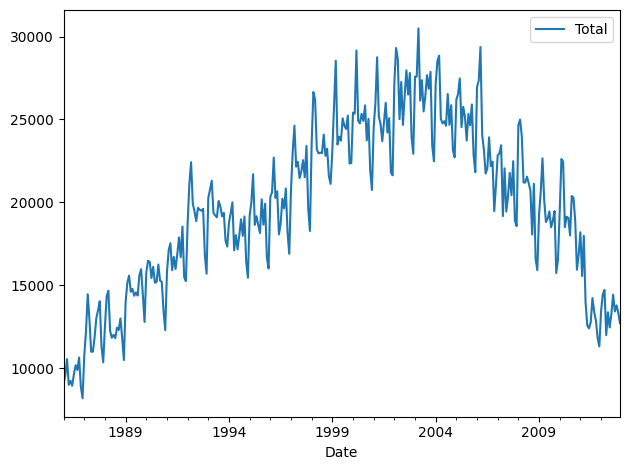

In [9]:
df['Total'].plot(legend=True)
plt.tight_layout()
plt.show()

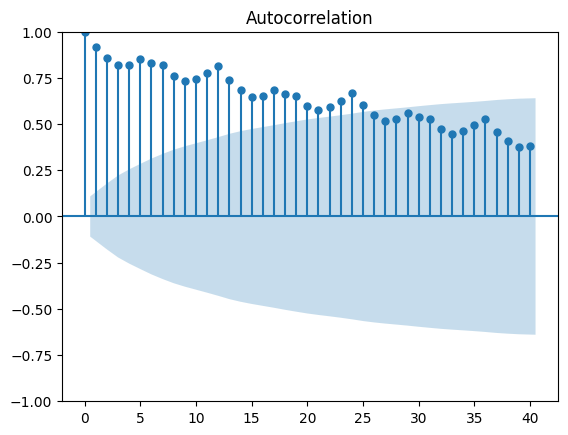

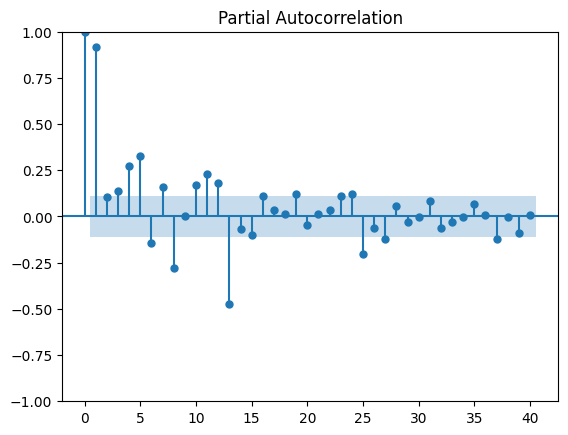

In [10]:
plot_acf(df['Total'],lags=40)
plot_pacf(df['Total'], lags=40)
plt.show()

In [17]:
train_size = int(len(df) * 0.80)
train_data, test_data = df[0:train_size], df[train_size:]

In [18]:
start=len(train_data)
end=len(train_data)+ len(test_data)-1
start,end

(259, 323)

In [20]:
model_4=ARIMA(train_data,order=(1,0,1))
model_4=model_4.fit()
model_4.summary()

d:\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Total   No. Observations:                  259
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -2318.444
Date:                Tue, 11 Aug 2026   AIC                           4644.888
Time:                        18:13:48   BIC                           4659.115
Sample:                    01-01-1986   HQIC                          4650.608
                         - 07-01-2007                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.016e+04   5432.538      3.711      0.000    9513.218    3.08e+04
ar.L1          0.9963      0.006    177.199      0.000       0.985       1.007
ma.L1         -0.7030      0.046    -15.245      0.000      -0.793      -0.613
sigma2      3.445e+06     20.053   1.72e+05      0.000    3.45e+06    3.45e+06
===================================================================================
Ljung-Box (L1) (Q):                  20.16   Jarque-Bera (JB):                 4.52
Prob(Q):                              0.00   Prob(JB):                         0.10
Heteroskedasticity (H):               1.80   Skew:                             0.32
Prob(H) (two-sided):                  0.01   Kurtosis:                         2.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 8.38e+20. Standard errors may be unstable.
"""

In [22]:
pred_4=model_4.predict(start=start,end=end,type='levels')
pred_4

d:\anaconda\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['type']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


2007-08-01    20849.730228
2007-09-01    20847.163049
2007-10-01    20844.605435
2007-11-01    20842.057353
2007-12-01    20839.518765
                  ...     
2012-08-01    20711.473810
2012-09-01    20709.421816
2012-10-01    20707.377469
2012-11-01    20705.340740
2012-12-01    20703.311601
Freq: MS, Name: predicted_mean, Length: 65, dtype: float64

In [23]:
pred_4.index=df.index[start:end+1]
pred_4.index

DatetimeIndex(['2007-08-01', '2007-09-01', '2007-10-01', '2007-11-01',
               '2007-12-01', '2008-01-01', '2008-02-01', '2008-03-01',
               '2008-04-01', '2008-05-01', '2008-06-01', '2008-07-01',
               '2008-08-01', '2008-09-01', '2008-10-01', '2008-11-01',
               '2008-12-01', '2009-01-01', '2009-02-01', '2009-03-01',
               '2009-04-01', '2009-05-01', '2009-06-01', '2009-07-01',
               '2009-08-01', '2009-09-01', '2009-10-01', '2009-11-01',
               '2009-12-01', '2010-01-01', '2010-02-01', '2010-03-01',
               '2010-04-01', '2010-05-01', '2010-06-01', '2010-07-01',
               '2010-08-01', '2010-09-01', '2010-10-01', '2010-11-01',
               '2010-12-01', '2011-01-01', '2011-02-01', '2011-03-01',
               '2011-04-01', '2011-05-01', '2011-06-01', '2011-07-01',
               '2011-08-01', '2011-09-01', '2011-10-01', '2011-11-01',
               '2011-12-01', '2012-01-01', '2012-02-01', '2012-03-01',
      

<Axes: xlabel='Date'>

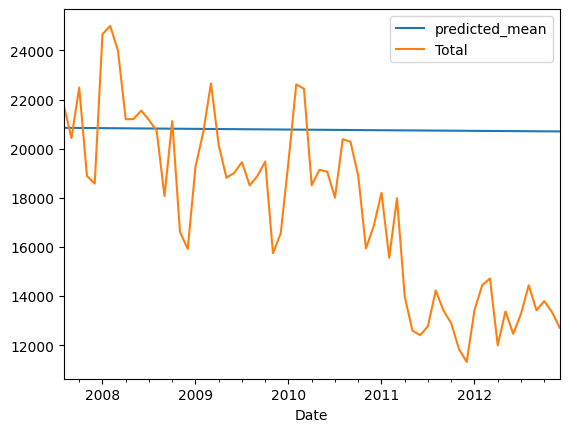

In [16]:
pred_4.plot(legend=True)
test_data['Total'].plot(legend=True)

In [24]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(pred_4,test_data['Total'])
print(mae)

3844.498365464248


In [25]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series, max_diff_order=2, alpha=0.05):
    """
    Check stationarity of a time series using the Augmented Dickey-Fuller (ADF) test.
    If the series is not stationary, apply differencing recursively until stationarity is achieved.
    
    Parameters:
    - series: pandas Series, the time series data
    - max_diff_order: int, maximum order of differencing to be applied (default: 2)
    - alpha: float, significance level for ADF test (default: 0.05)
    
    Returns:
    - stationary_series: pandas Series, the stationary time series
    """
    # Perform ADF test
    adf_result = adfuller(series)
    p_value = adf_result[1]
    
    # If the series is already stationary, return the original series
    if p_value < alpha:
        print("Original series is stationary (p-value: {:.4f})".format(p_value))
        return series
    
    
    
    # If the series is not stationary, apply differencing
    print("Original series is not stationary (p-value: {:.4f}), applying differencing...".format(p_value))
    for diff_order in range(1, max_diff_order + 1):
        differenced_series = series.diff(diff_order).dropna()
        adf_result_diff = adfuller(differenced_series)
        p_value_diff = adf_result_diff[1]
        
        # Check stationarity after differencing
        if p_value_diff < alpha:
            print("Series after {} order differencing is stationary (p-value: {:.4f})".format(diff_order, p_value_diff))
            return differenced_series
        
    # If maximum differencing orders reached and still not stationary, return None
    print("Maximum differencing orders reached. Unable to achieve stationarity.")
    return None

# Example usage:
# Assuming 'time_series' is your pandas Series containing the time series data
# stationary_series = check_stationarity(time_series)

In [26]:
def difference(dataset, interval=1):
 diff = list()
 for i in range(interval, len(dataset)):
     value = dataset[i] - dataset[i - interval]
     diff.append(value)
 return Series(diff)

In [27]:
stat=check_stationarity(df['Total'])

Original series is not stationary (p-value: 0.4887), applying differencing...
Series after 1 order differencing is stationary (p-value: 0.0004)


In [65]:
def evaluate_arima_model(X, arima_order):
 # prepare training dataset
 train_size = int(len(X) * 0.80)
 train, test = X[0:train_size], X[train_size:]
 history = [x for x in train]
 predictions = list()
 for t in range(len(test)):
     model = ARIMA(history, order=arima_order)
     model_fit = model.fit()
     yhat = model_fit.forecast()[0]
     predictions.append(yhat)
     history.append(test.iloc[t])
 # # calculate out of sample error
 rmse = sqrt(mean_squared_error(test, predictions))
 return rmse,predictions

In [66]:
def evaluate_models(dataset, p_values, d_values, q_values):
    dataset = dataset.astype('float32')
    best_score, best_cfg = float("inf"), None
    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p,d,q)
                try:
                    rmse,predictions = evaluate_arima_model(dataset, order)
                    if rmse < best_score:
                        best_score, best_cfg = rmse, order
                    print('ARIMA%s RMSE=%.3f' % (order,rmse))
                except Exception as e:
                    print(f'ARIMA{order} FAILED -> {type(e).__name__}: {e}')
                    continue
    print('Best ARIMA%s RMSE=%.3f' % (best_cfg, best_score))
    return predictions

In [67]:
p_values = range(0,3)
d_values = range(0,3)
q_values = range(0,3)
warnings.filterwarnings("ignore")
predictions_f=evaluate_models(df['Total'], p_values, d_values, q_values)

ARIMA(0, 0, 0) RMSE=4291.542
ARIMA(0, 0, 1) RMSE=2752.009
ARIMA(0, 0, 2) RMSE=2667.483
ARIMA(0, 1, 0) RMSE=1981.805
ARIMA(0, 1, 1) RMSE=1957.827
ARIMA(0, 1, 2) RMSE=1842.939
ARIMA(0, 2, 0) RMSE=2997.527
ARIMA(0, 2, 1) RMSE=1989.022
ARIMA(0, 2, 2) RMSE=2026.467
ARIMA(1, 0, 0) RMSE=1950.944
ARIMA(1, 0, 1) RMSE=1967.729
ARIMA(1, 0, 2) RMSE=1853.138
ARIMA(1, 1, 0) RMSE=1964.315
ARIMA(1, 1, 1) RMSE=1860.605
ARIMA(1, 1, 2) RMSE=1845.211
ARIMA(1, 2, 0) RMSE=2672.917
ARIMA(1, 2, 1) RMSE=1972.648
ARIMA(1, 2, 2) RMSE=1971.875
ARIMA(2, 0, 0) RMSE=1944.413
ARIMA(2, 0, 1) RMSE=1871.080
ARIMA(2, 0, 2) RMSE=1847.608
ARIMA(2, 1, 0) RMSE=1912.153
ARIMA(2, 1, 1) RMSE=1840.219
ARIMA(2, 1, 2) RMSE=1934.269
ARIMA(2, 2, 0) RMSE=2499.561
ARIMA(2, 2, 1) RMSE=1920.847
ARIMA(2, 2, 2) RMSE=1903.642
Best ARIMA(2, 1, 1) RMSE=1840.219


# Auto ARIMA

## 1. What Is Auto ARIMA?

**Auto ARIMA** is an automated method for selecting a suitable **ARIMA model** for a time series.

When building an ARIMA model manually, we need to determine:

[
\boxed{ARIMA(p,d,q)}
]

where:

* (p) = AutoRegressive order
* (d) = Differencing order
* (q) = Moving Average order

For seasonal time series, we may additionally use:

[
\boxed{SARIMA(p,d,q)(P,D,Q)_s}
]

where:

* (P) = Seasonal AR order
* (D) = Seasonal differencing order
* (Q) = Seasonal MA order
* (s) = Seasonal period

Finding these parameters manually can require fitting and comparing many different model combinations.

**Auto ARIMA automates much of this model-selection process.**

Instead of manually testing:

[
ARIMA(1,1,1)
]

[
ARIMA(2,1,1)
]

[
ARIMA(1,1,2)
]

[
ARIMA(2,1,2)
]

and many others, Auto ARIMA searches through a specified range of possible models and selects a model according to a model-selection criterion such as **AIC**.

---

# 2. Why Do We Need Auto ARIMA?

Suppose we have a time series and do not know the correct values of (p), (d), and (q).

We could manually fit many models:

```text
ARIMA(0,0,0)
ARIMA(0,0,1)
ARIMA(0,1,0)
ARIMA(0,1,1)
ARIMA(1,0,0)
ARIMA(1,0,1)
ARIMA(1,1,0)
ARIMA(1,1,1)
ARIMA(2,1,1)
...
```

As the possible values of (p), (d), and (q) increase, the number of candidate models also increases.

Auto ARIMA automates this search.

```text
                  Time Series
                       │
                       ▼
                  Auto ARIMA
                       │
             ┌─────────┼─────────┐
             ▼         ▼         ▼
             p         d         q
             │         │         │
             └─────────┼─────────┘
                       ▼
               Candidate Models
                       │
                       ▼
                   AIC / BIC
                       │
                       ▼
                Selected Model
```

The exact search strategy depends on the implementation and the settings used.

---

# 3. Auto ARIMA vs. ARIMA

## ARIMA

With ordinary ARIMA modeling, we manually select:

[
\boxed{p,d,q}
]

For example:

[
ARIMA(2,1,1)
]

means:

[
p=2,\qquad d=1,\qquad q=1
]

We might determine these values using:

* Stationarity tests
* Differencing
* ACF
* PACF
* AIC
* BIC
* Residual diagnostics

---

## Auto ARIMA

Auto ARIMA searches through multiple combinations of:

[
(p,d,q)
]

and selects a suitable model according to a specified information criterion.

Therefore:

[
\boxed{
\text{Auto ARIMA}
=================

\text{Automated ARIMA Model Selection}
}
]

Auto ARIMA is therefore better understood as a **model-selection procedure**, rather than a completely different forecasting model.

---

# 4. What Does Auto ARIMA Actually Automate?

For non-seasonal ARIMA, Auto ARIMA can search over:

[
p,d,q
]

For seasonal ARIMA, it can additionally search over:

[
P,D,Q
]

while the seasonal period (s) is generally supplied by the user based on the frequency of the data.

Therefore, for seasonal data:

[
\boxed{
SARIMA(p,d,q)(P,D,Q)_s
}
]

can be selected automatically within the specified search space.

> **Important:** Auto ARIMA primarily automates the process of finding a suitable ARIMA/SARIMA specification. It does not mean that forecasting, validation, and residual diagnostics can be skipped.

---

# 5. Understanding (p), (d), and (q)

Recall:

[
\boxed{
ARIMA(p,d,q)
}
]

where:

### (p) — AutoRegressive order

The number of autoregressive terms.

[
\boxed{
p=\text{AR order}
}
]

### (d) — Differencing order

The number of times the series is differenced.

[
\boxed{
d=\text{Differencing order}
}
]

### (q) — Moving Average order

The number of moving-average error terms.

[
\boxed{
q=\text{MA order}
}
]

Auto ARIMA searches over possible combinations of these parameters.

---

# 6. How Auto ARIMA Works

A simplified Auto ARIMA process is:

```text
                Original Time Series
                         │
                         ▼
                  Check Stationarity
                         │
                         ▼
                  Determine d
                         │
                         ▼
                Generate Candidate
                  ARIMA Models
                         │
                         ▼
                    Fit Models
                         │
                         ▼
                 Calculate AIC/BIC
                         │
                         ▼
                  Compare Models
                         │
                         ▼
                 Select Model
                         │
                         ▼
                    Forecast
```

For example, suppose we specify:

```text
p = 0 to 3
d = 0 to 2
q = 0 to 3
```

The search may consider models such as:

[
ARIMA(0,0,0)
]

[
ARIMA(0,0,1)
]

[
ARIMA(0,1,1)
]

[
ARIMA(1,1,1)
]

[
ARIMA(2,1,1)
]

and many others within the allowed search space.

---

# 7. AIC in Auto ARIMA

One of the most commonly used model-selection criteria is **AIC**.

AIC stands for:

> **Akaike Information Criterion**

The formula is:

[
\boxed{
AIC=-2\ln(L)+2k
}
]

where:

* (L) = maximum likelihood of the model
* (k) = number of estimated parameters

AIC balances:

[
\boxed{
\text{Model Fit}+\text{Model Complexity}
}
]

Generally:

[
\boxed{
\text{Lower AIC}=\text{Better according to AIC}
}
]

---

# 8. BIC in Auto ARIMA

Another model-selection criterion is **BIC**.

BIC stands for:

> **Bayesian Information Criterion**

The formula is:

[
\boxed{
BIC=-2\ln(L)+k\ln(n)
}
]

where:

* (L) = maximum likelihood
* (k) = number of estimated parameters
* (n) = number of observations

BIC generally applies a stronger complexity penalty than AIC as the sample size becomes sufficiently large.

Therefore:

[
\boxed{
\text{Lower BIC}=\text{Better according to BIC}
}
]

---

# 9. AIC vs. BIC in Auto ARIMA

Suppose Auto ARIMA evaluates the following models:

| Model        | AIC | BIC |
| ------------ | --: | --: |
| ARIMA(1,1,1) | 520 | 528 |
| ARIMA(2,1,1) | 515 | 526 |
| ARIMA(2,1,2) | 513 | 529 |

According to AIC:

[
513 < 515 < 520
]

Therefore, AIC selects:

[
\boxed{ARIMA(2,1,2)}
]

According to BIC:

[
526 < 528 < 529
]

Therefore, BIC selects:

[
\boxed{ARIMA(2,1,1)}
]

This demonstrates that different information criteria can select different models.

---

# 10. Auto ARIMA and the ADF Test

The **Augmented Dickey-Fuller (ADF) test** can be used to investigate whether a time series is stationary.

### Null Hypothesis

[
H_0:
\text{The series has a unit root}
]

A unit root generally indicates non-stationarity.

### Alternative Hypothesis

[
H_1:
\text{The series is stationary}
]

If:

[
p\text{-value}<0.05
]

we generally reject (H_0), providing evidence that the series is stationary.

If:

[
p\text{-value}>0.05
]

we generally fail to reject (H_0), suggesting that differencing may be required.

Auto ARIMA implementations can use statistical tests and/or other procedures to determine appropriate differencing orders, depending on their configuration.

---

# 11. Manual ARIMA vs. Auto ARIMA

## Manual Approach

```text
ADF Test
   ↓
Determine d
   ↓
ACF + PACF
   ↓
Determine p and q
   ↓
Fit ARIMA Models
   ↓
Compare AIC/BIC
   ↓
Select Model
   ↓
Check Residuals
   ↓
Validate Forecast
```

## Auto ARIMA

```text
              Time Series
                   │
                   ▼
              Auto ARIMA
                   │
        ┌──────────┼──────────┐
        ▼          ▼          ▼
        p          d          q
        └──────────┼──────────┘
                   ▼
           Candidate Models
                   │
                   ▼
               AIC/BIC
                   │
                   ▼
            Selected Model
```

Auto ARIMA reduces the amount of manual parameter selection.

However, understanding ACF, PACF, stationarity, and residual diagnostics remains important.

---

# 12. ACF and PACF vs. Auto ARIMA

Previously, we learned:

[
\boxed{
ACF\rightarrow q
}
]

[
\boxed{
PACF\rightarrow p
}
]

These are useful rules of thumb when manually identifying ARIMA models.

With Auto ARIMA, we do not necessarily need to determine (p) and (q) entirely from ACF and PACF.

Instead, Auto ARIMA can search through candidate values.

### Manual ARIMA

```text
ACF + PACF
     ↓
Determine p and q
     ↓
Fit Candidate Models
```

### Auto ARIMA

```text
Candidate p and q values
          ↓
      Model Search
          ↓
        AIC/BIC
          ↓
      Best Model
```

ACF and PACF are still valuable for understanding the autocorrelation structure and for narrowing the search space.

---

# 13. Auto ARIMA for SARIMA

Auto ARIMA can also be used for seasonal time series.

Recall:

[
\boxed{
SARIMA(p,d,q)(P,D,Q)_s
}
]

For monthly data with yearly seasonality:

[
s=12
]

Auto ARIMA can search over:

[
p,d,q,P,D,Q
]

while the seasonal period (s) is generally supplied based on the data frequency.

For example:

[
\boxed{
SARIMA(p,d,q)(P,D,Q)_{12}
}
]

---

# 14. Seasonal Auto ARIMA

For seasonal data, the workflow becomes:

```text
                  Time Series
                       │
                       ▼
                Identify Seasonality
                       │
                       ▼
                    Set s
                       │
                       ▼
                  Auto ARIMA
                       │
             ┌─────────┴─────────┐
             ▼                   ▼
        Non-seasonal           Seasonal
          p, d, q               P, D, Q
             │                   │
             └─────────┬─────────┘
                       ▼
                Candidate Models
                       │
                       ▼
                    AIC/BIC
                       │
                       ▼
                 Best SARIMA
                       │
                       ▼
                    Forecast
```

---

# 15. Python Library — `pmdarima`

A commonly used Python implementation of Auto ARIMA is provided by the `pmdarima` package.

Install it with:

```bash
pip install pmdarima
```

Then import:

```python
from pmdarima import auto_arima
```

> **Note:** Package compatibility can depend on your Python version and installed NumPy/SciPy versions. If `pmdarima` gives installation or binary-compatibility errors, check the package's current compatibility requirements.

---

# 16. Basic Auto ARIMA Example

```python
from pmdarima import auto_arima

model = auto_arima(
    series_3,
    seasonal=False,
    trace=True
)

print(model.summary())
```

Here:

```python
seasonal=False
```

means that we are searching for a **non-seasonal ARIMA model**.

---

# 17. Understanding `trace=True`

The parameter:

```python
trace=True
```

allows the model-search process to be displayed.

You may see output similar to:

```text
ARIMA(0,1,0)
ARIMA(0,1,1)
ARIMA(1,1,0)
ARIMA(1,1,1)
ARIMA(2,1,1)
...
```

along with information-criterion values.

This allows you to observe which candidate models are being evaluated.

---

# 18. Limiting the Search Space

We can control the maximum values of (p), (q), and (d).

```python
from pmdarima import auto_arima

model = auto_arima(
    series_3,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    max_d=2,
    seasonal=False,
    trace=True
)

print(model.summary())
```

Here:

```text
start_p = 0
start_q = 0

max_p = 3
max_q = 3

max_d = 2
```

means that the search is constrained to the specified ranges.

---

# 19. Seasonal Auto ARIMA in Python

For monthly data with yearly seasonality:

[
s=12
]

we can use:

```python
from pmdarima import auto_arima

model = auto_arima(
    series_3,
    seasonal=True,
    m=12,
    trace=True
)

print(model.summary())
```

Here:

```python
seasonal=True
```

means seasonal terms are included.

And:

```python
m=12
```

specifies that one seasonal cycle contains 12 observations.

Therefore, the model can search for a seasonal ARIMA specification of the form:

[
SARIMA(p,d,q)(P,D,Q)_{12}
]

---

# 20. Understanding `m` in Auto ARIMA

The parameter:

```python
m
```

represents the number of observations in one seasonal cycle.

Examples:

| Data Frequency | Seasonal Pattern | `m` |
| -------------- | ---------------- | --: |
| Monthly        | Yearly           |  12 |
| Quarterly      | Yearly           |   4 |
| Daily          | Weekly           |   7 |
| Hourly         | Daily            |  24 |

Therefore, in the Auto ARIMA context:

[
\boxed{
m=s
}
]

where (s) is the seasonal period.

> **Important:** `m` should represent the seasonal cycle you actually want to model. A dataset's sampling frequency and its seasonal period are related, but they are not necessarily the same thing.

---

# 21. Getting the Selected Model

After fitting:

```python
model = auto_arima(
    series_3,
    seasonal=False,
    trace=True
)
```

we can obtain the selected non-seasonal order using:

```python
print(model.order)
```

Suppose the output is:

```text
(2, 1, 1)
```

This means:

[
\boxed{
ARIMA(2,1,1)
}
]

Therefore:

```text
p = 2
d = 1
q = 1
```

---

# 22. Getting the Seasonal Order

For seasonal Auto ARIMA:

```python
print(model.order)
print(model.seasonal_order)
```

Suppose the output is:

```text
order:
(1, 1, 1)

seasonal_order:
(1, 1, 1, 12)
```

Then the selected model is:

[
\boxed{
SARIMA(1,1,1)(1,1,1)_{12}
}
]

---

# 23. Forecasting Using Auto ARIMA

Once Auto ARIMA has selected and fitted the model:

```python
forecast = model.predict(n_periods=12)

print(forecast)
```

This forecasts the next 12 observations.

For monthly data:

```python
n_periods=12
```

means:

> Forecast the next 12 months.

---

# 24. Plotting the Forecast

```python
import matplotlib.pyplot as plt

forecast = model.predict(n_periods=12)

plt.figure(figsize=(12, 5))

plt.plot(
    series_3,
    label="Actual"
)

plt.plot(
    forecast,
    label="Forecast"
)

plt.legend()
plt.show()
```

---

# 25. Train-Test Split with Auto ARIMA

For proper evaluation, we should separate the data into training and testing sets.

For example:

```python
train = series_3.iloc[:-12]
test = series_3.iloc[-12:]
```

Here:

```text
Training data → All observations except the last 12
Testing data  → Last 12 observations
```

Then fit Auto ARIMA **only on the training data**:

```python
model = auto_arima(
    train,
    seasonal=True,
    m=12,
    trace=True
)
```

Forecast the same number of periods as the test set:

```python
predictions = model.predict(
    n_periods=len(test)
)
```

---

# 26. Evaluating Auto ARIMA

We can calculate RMSE using:

```python
from sklearn.metrics import mean_squared_error
from math import sqrt

rmse = sqrt(
    mean_squared_error(
        test,
        predictions
    )
)

print("RMSE:", rmse)
```

The RMSE formula is:

[
\boxed{
RMSE=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
}
}
]

Lower RMSE generally indicates better forecast performance on the evaluation data.

> **Important:** `test` and `predictions` must represent the same number of observations and be aligned to the same forecast horizon.

---

# 27. AIC vs. RMSE

This distinction is extremely important.

### AIC

Primarily used for:

> **Comparing statistical models**

[
\boxed{
AIC\rightarrow\text{Model Selection}
}
]

### RMSE

Used for:

> **Evaluating forecast errors on data**

[
\boxed{
RMSE\rightarrow\text{Forecast Evaluation}
}
]

A model can have the lowest AIC but not necessarily the lowest test-set RMSE.

Therefore:

[
\boxed{
\text{Lowest AIC}
\neq
\text{Guaranteed Best Forecast}
}
]

---

# 28. Auto ARIMA Does Not Replace Validation

Auto ARIMA selects a model according to its search criterion and configuration.

However, we should still evaluate the selected model on unseen data.

A proper workflow is:

```text
                 Full Time Series
                       │
                       ▼
                 Train/Test Split
                       │
             ┌─────────┴─────────┐
             ▼                   ▼
           Train                Test
             │
             ▼
        Auto ARIMA
             │
             ▼
      Selected ARIMA/SARIMA
             │
             ▼
          Forecast
             │
             └──────────────► Compare with Test
                                  │
                                  ▼
                              RMSE / MAE
```

---

# 29. Auto ARIMA vs. Grid Search

There are two common approaches to searching for ARIMA parameters.

## Grid Search

Suppose we define:

```text
p = 0, 1, 2
d = 0, 1
q = 0, 1, 2
```

A complete grid search would contain:

[
3\times2\times3=18
]

possible combinations.

Each candidate model can then be fitted and evaluated.

---

## Auto ARIMA

Auto ARIMA automates the search over the specified parameter space.

Depending on the implementation and configuration, it may use a **stepwise search** rather than evaluating every possible combination.

Therefore:

[
\boxed{
\text{Auto ARIMA}
=================

\text{Automated Model Search}
}
]

---

# 30. Stepwise Search

Some Auto ARIMA implementations can use a **stepwise search strategy**.

Instead of blindly testing every possible combination, the algorithm evaluates promising models and moves through the model space.

Conceptually:

```text
          Initial Model
               │
               ▼
        Evaluate Model
               │
               ▼
       Try Candidate Model
               │
               ▼
        Evaluate Candidate
               │
               ▼
       Improvement Found?
          ↙          ↘
        Yes           No
         │             │
         ▼             ▼
   Continue Search    Stop
         │
         ▼
    Selected Model
```

This can reduce computational cost compared with evaluating every possible combination.

---

# 31. `stepwise=True`

For example:

```python
from pmdarima import auto_arima

model = auto_arima(
    series_3,
    seasonal=True,
    m=12,
    stepwise=True,
    trace=True
)

print(model.summary())
```

The exact search behavior depends on the implementation and settings.

The important idea is:

> **Stepwise search attempts to find a good model without necessarily evaluating every possible parameter combination.**

---

# 32. Important Auto ARIMA Parameters

Some commonly used parameters include:

| Parameter               | Meaning                                 |
| ----------------------- | --------------------------------------- |
| `start_p`               | Starting value for non-seasonal (p)     |
| `start_q`               | Starting value for non-seasonal (q)     |
| `max_p`                 | Maximum non-seasonal (p)                |
| `max_q`                 | Maximum non-seasonal (q)                |
| `max_d`                 | Maximum non-seasonal differencing order |
| `seasonal`              | Whether seasonal terms are included     |
| `m`                     | Seasonal period                         |
| `start_P`               | Starting seasonal (P)                   |
| `start_Q`               | Starting seasonal (Q)                   |
| `max_P`                 | Maximum seasonal (P)                    |
| `max_Q`                 | Maximum seasonal (Q)                    |
| `max_D`                 | Maximum seasonal differencing order     |
| `trace`                 | Displays model-search progress          |
| `stepwise`              | Enables stepwise search                 |
| `information_criterion` | Criterion used for model selection      |

---

# 33. Example with More Control

```python
from pmdarima import auto_arima

model = auto_arima(
    train,

    start_p=0,
    start_q=0,

    max_p=3,
    max_q=3,

    max_d=2,

    start_P=0,
    start_Q=0,

    max_P=2,
    max_Q=2,

    max_D=1,

    seasonal=True,
    m=12,

    stepwise=True,
    trace=True,

    information_criterion="aic"
)

print(model.summary())
```

This allows us to control the size of the model-search space.

---

# 34. Understanding the Selected Model

Suppose Auto ARIMA gives:

```text
ARIMA(1,1,2)(1,1,1)[12]
```

The non-seasonal component is:

[
p=1,\qquad d=1,\qquad q=2
]

The seasonal component is:

[
P=1,\qquad D=1,\qquad Q=1
]

The seasonal period is:

[
s=12
]

Therefore:

[
\boxed{
SARIMA(1,1,2)(1,1,1)_{12}
}
]

---

# 35. Auto ARIMA Workflow for Monthly Data

For monthly time-series data, a practical workflow is:

```text
                 Monthly Time Series
                         │
                         ▼
                  Plot the Series
                         │
                         ▼
                Identify Seasonality
                         │
                         ▼
                       m = 12
                         │
                         ▼
                  Train / Test Split
                         │
                         ▼
                    Auto ARIMA
                         │
                         ▼
              Search p,d,q,P,D,Q
                         │
                         ▼
                    AIC / BIC
                         │
                         ▼
                 Selected SARIMA
                         │
                         ▼
                     Forecast
                         │
                         ▼
                  Test-set RMSE
                         │
                         ▼
                 Residual Analysis
```

---

# 36. Auto ARIMA vs. Manual ARIMA

| Aspect          | Manual ARIMA              | Auto ARIMA                      |
| --------------- | ------------------------- | ------------------------------- |
| Choose (p)      | Manually                  | Automatically searched          |
| Choose (d)      | Differencing/tests        | Can be automated                |
| Choose (q)      | Manually                  | Automatically searched          |
| ACF/PACF        | Very useful               | Helpful but not mandatory       |
| Model search    | Manual                    | Automated                       |
| AIC/BIC         | Usually compared manually | Used during automated selection |
| Seasonal search | Manual                    | Can be automated                |
| Understanding   | Excellent for learning    | Faster for practical modeling   |
| Control         | High                      | Depends on search settings      |

---

# 37. Advantages of Auto ARIMA

## 1. Saves Time

It avoids manually fitting and comparing a large number of candidate models.

## 2. Automates Parameter Search

It can search over:

[
p,d,q
]

and, for seasonal models:

[
P,D,Q
]

## 3. Useful for Baseline Models

Auto ARIMA can provide a useful classical forecasting baseline.

## 4. Can Handle Seasonality

When configured appropriately:

```python
seasonal=True
```

the procedure can search seasonal ARIMA models.

## 5. Uses Information Criteria

Depending on the implementation, Auto ARIMA can compare models using criteria such as:

* AIC
* AICc
* BIC

and other supported criteria.

---

# 38. Limitations of Auto ARIMA

Auto ARIMA is useful, but it is not a magic forecasting algorithm.

## 1. It Depends on the Search Space

If we specify:

```python
max_p=2
```

the search will not consider:

[
p>2
]

Therefore, poorly chosen parameter limits can prevent the algorithm from finding a suitable model.

---

## 2. AIC Does Not Guarantee the Best Forecast

The model with the lowest AIC does not necessarily have the lowest test-set RMSE.

Therefore:

[
\boxed{
AIC\neq\text{Forecast Accuracy}
}
]

Out-of-sample validation is still necessary.

---

## 3. It Can Be Computationally Expensive

If the search space is large and many models must be fitted, the procedure can take considerable time.

---

## 4. It Does Not Automatically Solve Every Time-Series Problem

Some time series may require:

* Transformations
* External variables
* Structural-break handling
* More advanced seasonal models
* Machine-learning models
* Other forecasting approaches

Auto ARIMA should therefore be viewed as one forecasting approach rather than a universal solution.

---

# 39. Auto ARIMA and Exogenous Variables

Sometimes the target variable depends on external variables.

For example:

```text
                         Sales
                           ↑
             ┌─────────────┼─────────────┐
             │             │             │
        Previous Sales   Price      Advertising
                           │
                       Temperature
```

These external variables are called **exogenous variables**.

They can be supplied using `X`.

For example:

```python
model = auto_arima(
    y=train_y,
    X=train_X,
    seasonal=True,
    m=12
)
```

This corresponds to an ARIMA/SARIMA model with exogenous regressors, commonly associated with the **ARIMAX/SARIMAX** framework.

For forecasting, future values of the exogenous variables must also be available:

```python
predictions = model.predict(
    n_periods=len(test),
    X=test_X
)
```

---

# 40. Important Difference: Auto ARIMA vs. SARIMA

### SARIMA

SARIMA is the **statistical model**:

[
\boxed{
SARIMA(p,d,q)(P,D,Q)_s
}
]

### Auto ARIMA

Auto ARIMA is the **model-selection procedure**:

[
\boxed{
\text{Search for suitable ARIMA/SARIMA parameters}
}
]

Therefore:

[
\boxed{
SARIMA=\text{Seasonal Model}
}
]

while:

[
\boxed{
Auto\ ARIMA=\text{Automated Model Selection}
}
]

This distinction is very important.

---

# 41. Auto ARIMA and Previously Learned Concepts

We can connect Auto ARIMA with the concepts learned earlier.

## ADF

Used to investigate stationarity and determine whether differencing may be necessary:

[
\boxed{
ADF\rightarrow d,D
}
]

However, this is a conceptual relationship rather than a strict rule because the exact method used to determine (d) and (D) depends on the implementation.

---

## ACF

Used to understand autocorrelation and can help identify MA terms:

[
\boxed{
ACF\rightarrow q,Q
}
]

---

## PACF

Used to understand partial autocorrelation and can help identify AR terms:

[
\boxed{
PACF\rightarrow p,P
}
]

---

## Auto ARIMA

Automates much of the parameter search:

[
\boxed{
Auto\ ARIMA
\rightarrow
p,d,q,P,D,Q
}
]

within the specified search space.

---

## AIC/BIC

Used for model comparison:

[
\boxed{
AIC/BIC
\rightarrow
\text{Model Selection}
}
]

---

## RMSE/MAE

Used to evaluate forecast performance:

[
\boxed{
RMSE/MAE
\rightarrow
\text{Forecast Evaluation}
}
]

---

# 42. Complete Time-Series Modeling Picture

```text
                         TIME SERIES
                              │
                              ▼
                       Explore the Data
                              │
                              ▼
                  Trend + Seasonality Check
                              │
                              ▼
                     Stationarity Check
                              │
                              ▼
                          ADF Test
                              │
                              ▼
                    Differencing: d, D
                              │
                              ▼
                       ACF + PACF
                              │
                              ▼
                ┌──────────────────────────┐
                │   Manual ARIMA/SARIMA    │
                │           OR             │
                │        Auto ARIMA        │
                └────────────┬─────────────┘
                             │
                             ▼
                       Candidate Models
                             │
                             ▼
                         AIC / BIC
                             │
                             ▼
                      Selected Model
                             │
                             ▼
                     Residual Analysis
                             │
                             ▼
                    Test-Set Forecast
                             │
                             ▼
                         RMSE / MAE
                             │
                             ▼
                          Forecast
```

---

# 43. Key Things to Remember

## ARIMA

[
\boxed{
ARIMA(p,d,q)
}
]

where:

[
p=\text{AR order}
]

[
d=\text{Differencing order}
]

[
q=\text{MA order}
]

---

## SARIMA

[
\boxed{
SARIMA(p,d,q)(P,D,Q)_s
}
]

where:

* (p,d,q) = non-seasonal parameters
* (P,D,Q) = seasonal parameters
* (s) = seasonal period

---

## Auto ARIMA

> **Auto ARIMA automatically searches for a suitable ARIMA/SARIMA configuration within a specified search space.**

---

# 44. Most Important Relationships

[
\boxed{
ADF\rightarrow d,D
}
]

[
\boxed{
PACF\rightarrow p,P
}
]

[
\boxed{
ACF\rightarrow q,Q
}
]

[
\boxed{
Auto\ ARIMA
\rightarrow
\text{Automated Parameter Search}
}
]

[
\boxed{
AIC/BIC
\rightarrow
\text{Model Selection}
}
]

[
\boxed{
RMSE/MAE
\rightarrow
\text{Forecast Evaluation}
}
]

---

# 45. One-Line Memory Trick

> **ARIMA tells you how to model the series, SARIMA adds seasonality, and Auto ARIMA helps you automatically find a suitable ARIMA/SARIMA configuration.**

Therefore:

[
\boxed{
\text{ARIMA}=\text{Model}
}
]

[
\boxed{
\text{SARIMA}=\text{Seasonal Model}
}
]

[
\boxed{
\text{Auto ARIMA}=\text{Automated Model Selection}
}
]

---

# 46. Final Summary

| Concept               | Main Purpose                                                |
| --------------------- | ----------------------------------------------------------- |
| **ARIMA**             | Non-seasonal time-series model                              |
| **SARIMA**            | ARIMA model with seasonal components                        |
| **Auto ARIMA**        | Automatically searches for suitable ARIMA/SARIMA parameters |
| **ADF Test**          | Investigates stationarity                                   |
| **Differencing**      | Helps make a non-stationary series stationary               |
| **ACF**               | Helps identify MA structure                                 |
| **PACF**              | Helps identify AR structure                                 |
| **AIC/BIC**           | Compare candidate statistical models                        |
| **Residual Analysis** | Checks whether unexplained structure remains                |
| **RMSE/MAE**          | Evaluates out-of-sample forecasting performance             |

### The Complete Idea

[
\boxed{
\text{Explore}
\rightarrow
\text{Stationarity}
\rightarrow
\text{Differencing}
\rightarrow
\text{ACF/PACF}
\rightarrow
\text{Auto ARIMA}
\rightarrow
\text{AIC/BIC}
\rightarrow
\text{Residual Diagnostics}
\rightarrow
\text{Test-Set Evaluation}
\rightarrow
\text{Forecast}
}
]

The most important distinction is:

[
\boxed{
\text{Auto ARIMA selects a model; it does not replace model validation.}
}
]

A strong forecasting workflow should therefore combine **automated model selection**, **residual diagnostics**, and **out-of-sample evaluation** rather than relying only on the model's AIC or BIC.

### AutoARIMA

In [68]:
stepwise_fit_2=auto_arima(train_data,start_p=0, start_q=0,d=1,
                           max_p=40, max_q=40,information_criterion='bic',trace=True,suppress_warnings=True,stepwise=True,seasonal=False)
stepwise_fit_2.summary()

Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : BIC=4649.232, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : BIC=4649.084, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : BIC=4638.067, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : BIC=4643.814, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : BIC=4607.085, Time=0.17 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : BIC=4602.170, Time=0.18 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : BIC=4649.248, Time=0.07 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : BIC=4583.298, Time=0.16 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : BIC=4612.777, Time=0.05 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : BIC=4559.523, Time=0.19 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : BIC=4568.196, Time=0.07 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : BIC=4564.788, Time=0.18 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : BIC=inf, Time=0.41 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : BIC=4542.279, Time=0.30 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : 

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  259
Model:               SARIMAX(4, 1, 3)   Log Likelihood               -2231.495
Date:                Tue, 11 Aug 2026   AIC                           4478.991
Time:                        22:25:49   BIC                           4507.414
Sample:                    01-01-1986   HQIC                          4490.420
                         - 07-01-2007                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0315      0.083    -12.426      0.000      -1.194      -0.869
ar.L2         -0.3178      0.146     -2.172      0.030      -0.605      -0.031
ar.L3         -0.2223      0.135     -1.651      0.099      -0.486       0.042
ar.L4         -0.5289      0.071     -7.498      0.000      -0.667      -0.391
ma.L1          0.9693      0.091     10.632      0.000       0.791       1.148
ma.L2         -0.2427      0.151     -1.606      0.108      -0.539       0.053
ma.L3         -0.6655      0.096     -6.965      0.000      -0.853      -0.478
sigma2      2.131e+06   1.17e-08   1.82e+14      0.000    2.13e+06    2.13e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.73   Jarque-Bera (JB):                 3.49
Prob(Q):                              0.39   Prob(JB):                         0.17
Heteroskedasticity (H):               1.42   Skew:                             0.27
Prob(H) (two-sided):                  0.11   Kurtosis:                         2.82
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 9.61e+29. Standard errors may be unstable.
"""

In [69]:
model_3=ARIMA(train_data,order=(4,1,3))
model_3=model_3.fit()
model_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Total   No. Observations:                  259
Model:                 ARIMA(4, 1, 3)   Log Likelihood               -2231.495
Date:                Tue, 11 Aug 2026   AIC                           4478.991
Time:                        22:38:49   BIC                           4507.414
Sample:                    01-01-1986   HQIC                          4490.420
                         - 07-01-2007                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0315      0.083    -12.426      0.000      -1.194      -0.869
ar.L2         -0.3178      0.146     -2.172      0.030      -0.605      -0.031
ar.L3         -0.2223      0.135     -1.651      0.099      -0.486       0.042
ar.L4         -0.5289      0.071     -7.498      0.000      -0.667      -0.391
ma.L1          0.9693      0.091     10.632      0.000       0.791       1.148
ma.L2         -0.2427      0.151     -1.606      0.108      -0.539       0.053
ma.L3         -0.6655      0.096     -6.965      0.000      -0.853      -0.478
sigma2      2.131e+06   1.17e-08   1.82e+14      0.000    2.13e+06    2.13e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.73   Jarque-Bera (JB):                 3.49
Prob(Q):                              0.39   Prob(JB):                         0.17
Heteroskedasticity (H):               1.42   Skew:                             0.27
Prob(H) (two-sided):                  0.11   Kurtosis:                         2.82
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 9.61e+29. Standard errors may be unstable.
"""

In [71]:
pred_3=model_3.predict(start=start,end=end,type='levels')
pred_3

2007-08-01    22583.946406
2007-09-01    20998.578752
2007-10-01    22474.072509
2007-11-01    20475.280916
2007-12-01    21253.780081
                  ...     
2012-08-01    21961.410074
2012-09-01    20463.014255
2012-10-01    22195.473997
2012-11-01    20690.500620
2012-12-01    21568.649653
Freq: MS, Name: predicted_mean, Length: 65, dtype: float64

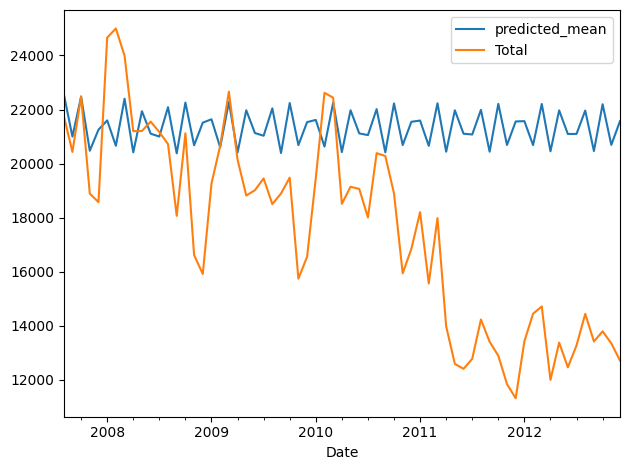

In [72]:
pred_3.plot(legend=True)
test_data['Total'].plot(legend=True)
plt.tight_layout()

In [73]:
from sklearn.metrics import mean_absolute_error
rmse=sqrt(mean_squared_error(pred_3,test_data['Total']))
print(rmse)

5182.343667723005


In [74]:
model_future=ARIMA(df['Total'],order=(4,1,3))
model_future=model_future.fit()

In [80]:
index_future=pd.date_range(start='2013-01-01',end='2013-08-01',freq='MS')
index_future

DatetimeIndex(['2013-01-01', '2013-02-01', '2013-03-01', '2013-04-01',
               '2013-05-01', '2013-06-01', '2013-07-01', '2013-08-01'],
              dtype='datetime64[us]', freq='MS')

In [81]:
pred_future=model_future.predict(start=len(df),end=len(df)+7,type='level')

In [82]:
pred_future

2013-01-01    12890.800297
2013-02-01    12496.334490
2013-03-01    14025.188104
2013-04-01    12807.931166
2013-05-01    13561.897305
2013-06-01    13067.118208
2013-07-01    12820.777900
2013-08-01    13709.835901
Freq: MS, Name: predicted_mean, dtype: float64

In [83]:
pred_future.index=index_future
pred_future

2013-01-01    12890.800297
2013-02-01    12496.334490
2013-03-01    14025.188104
2013-04-01    12807.931166
2013-05-01    13561.897305
2013-06-01    13067.118208
2013-07-01    12820.777900
2013-08-01    13709.835901
Freq: MS, Name: predicted_mean, dtype: float64

<Axes: >

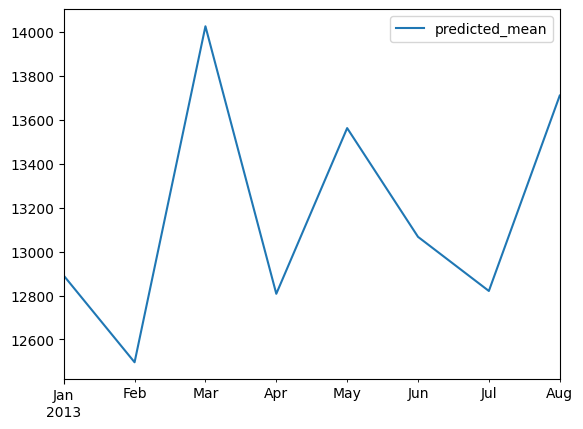

In [84]:
pred_future.plot(legend=True)

In [85]:
df_final=pd.DataFrame({'Date':pred_future.index, 'Total':pred_future.values})

In [86]:
df_final['Date'] = pd.to_datetime(df_final['Date'])

In [87]:
df_final.set_index('Date', inplace=True)

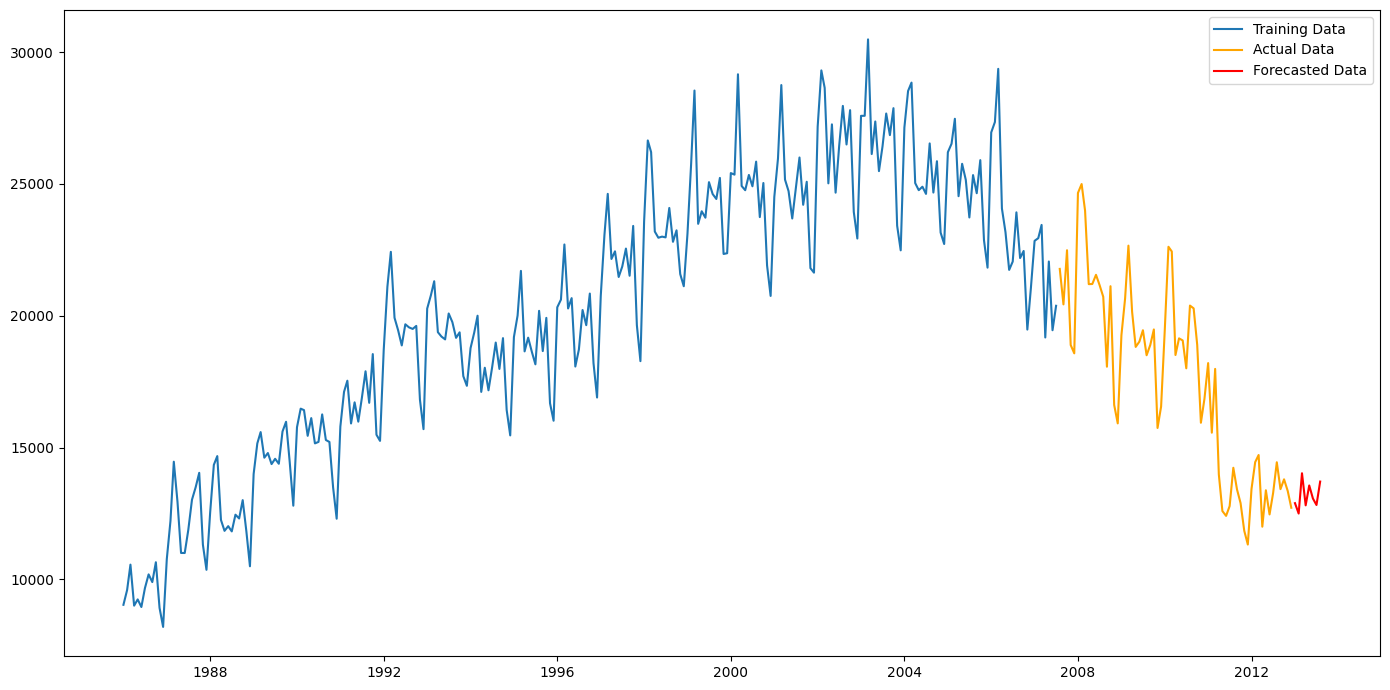

In [88]:
plt.figure(figsize=(14,7))
plt.plot(train_data.index,train_data['Total'],label='Training Data')
plt.plot(test_data.index,test_data['Total'], label='Actual Data', color='orange')
plt.plot(df_final.index ,df_final['Total'],label='Forecasted Data', color='red')

plt.legend()
plt.tight_layout()
plt.show()

#### Difference the series then apply auto_arima

In [92]:
def difference(dataset, interval=1):
 diff = list()
 for i in range(interval, len(dataset)):
     value = dataset.iloc[i] - dataset.iloc[i - interval]
     diff.append(value)
 return Series(diff)

In [93]:
cat_df=difference(df['Total'])

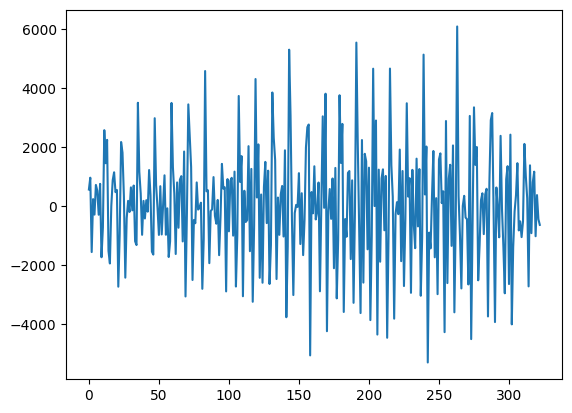

In [94]:
plt.plot(cat_df)

In [95]:
train_size = int(len(cat_df) * 0.80)
train_data_3, test_data_3 = cat_df[0:train_size], cat_df[train_size:]

In [96]:
stepwise_fit_3=auto_arima(train_data_3,start_p=0, start_q=0,d=0,
                           max_p=40, max_q=40,information_criterion='aic',trace=True,suppress_warnings=True,stepwise=True,seasonal=False)
stepwise_fit_3.summary()

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=4640.259, Time=0.12 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=4636.014, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=4620.778, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=4589.759, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=4581.145, Time=0.07 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=4631.805, Time=0.03 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=4560.965, Time=0.07 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=4592.058, Time=0.02 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=4527.872, Time=0.10 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=4541.545, Time=0.06 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=4529.510, Time=0.17 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=inf, Time=0.24 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.20 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=4541.663, Time=0.06 sec
 ARIMA(5,0,2)(0,0,0)[0]             : AIC=4

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  258
Model:              SARIMAX(13, 0, 1)   Log Likelihood               -2146.058
Date:                Tue, 11 Aug 2026   AIC                           4322.116
Time:                        23:03:06   BIC                           4375.410
Sample:                             0   HQIC                          4343.546
                                - 258                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1604      0.221      0.727      0.467      -0.272       0.593
ar.L2         -0.0845      0.069     -1.231      0.218      -0.219       0.050
ar.L3         -0.1005      0.072     -1.397      0.162      -0.241       0.040
ar.L4         -0.0153      0.071     -0.217      0.828      -0.153       0.123
ar.L5          0.0516      0.063      0.820      0.412      -0.072       0.175
ar.L6         -0.1217      0.058     -2.110      0.035      -0.235      -0.009
ar.L7          0.0925      0.068      1.361      0.173      -0.041       0.226
ar.L8         -0.0871      0.057     -1.531      0.126      -0.199       0.024
ar.L9         -0.0585      0.058     -1.004      0.316      -0.173       0.056
ar.L10         0.0060      0.056      0.107      0.915      -0.104       0.117
ar.L11         0.0026      0.058      0.045      0.964      -0.111       0.116
ar.L12         0.6826      0.052     13.192      0.000       0.581       0.784
ar.L13        -0.0800      0.154     -0.519      0.604      -0.382       0.222
ma.L1         -0.5543      0.206     -2.697      0.007      -0.957      -0.151
sigma2      9.826e+05   9.67e+04     10.162      0.000    7.93e+05    1.17e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.81
Prob(Q):                              0.98   Prob(JB):                         0.40
Heteroskedasticity (H):               1.66   Skew:                             0.20
Prob(H) (two-sided):                  0.02   Kurtosis:                         2.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [97]:
model_4=ARIMA(train_data_3,order=(13,0,1))
model_4=model_4.fit()
model_4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  258
Model:                ARIMA(13, 0, 1)   Log Likelihood               -2145.565
Date:                Tue, 11 Aug 2026   AIC                           4323.130
Time:                        23:03:37   BIC                           4379.978
Sample:                             0   HQIC                          4345.989
                                - 258                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         43.9691     46.384      0.948      0.343     -46.942     134.880
ar.L1          0.1399      0.242      0.578      0.563      -0.334       0.614
ar.L2         -0.0950      0.077     -1.234      0.217      -0.246       0.056
ar.L3         -0.1103      0.080     -1.385      0.166      -0.266       0.046
ar.L4         -0.0265      0.078     -0.342      0.732      -0.178       0.125
ar.L5          0.0415      0.069      0.606      0.545      -0.093       0.176
ar.L6         -0.1301      0.059     -2.207      0.027      -0.246      -0.015
ar.L7          0.0832      0.070      1.195      0.232      -0.053       0.220
ar.L8         -0.0944      0.057     -1.663      0.096      -0.206       0.017
ar.L9         -0.0673      0.061     -1.101      0.271      -0.187       0.052
ar.L10        -0.0037      0.059     -0.062      0.951      -0.120       0.113
ar.L11        -0.0068      0.062     -0.109      0.913      -0.129       0.115
ar.L12         0.6752      0.058     11.666      0.000       0.562       0.789
ar.L13        -0.0736      0.162     -0.453      0.650      -0.392       0.245
ma.L1         -0.5375      0.230     -2.336      0.019      -0.988      -0.087
sigma2      9.782e+05   9.79e+04      9.987      0.000    7.86e+05    1.17e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.67
Prob(Q):                              0.95   Prob(JB):                         0.43
Heteroskedasticity (H):               1.72   Skew:                             0.19
Prob(H) (two-sided):                  0.01   Kurtosis:                         2.92
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [99]:
pred_4=model_4.predict(start=start,end=end,type='levels')
pred_4

259   -1441.263207
260     560.002106
261   -2892.288505
262    1950.497304
263    1381.660678
          ...     
319    -999.555901
320     455.997680
321   -1531.281845
322    1438.765041
323     549.261895
Name: predicted_mean, Length: 65, dtype: float64

In [100]:
rmse=sqrt(mean_squared_error(pred_4,test_data['Total']))
print(rmse)

18078.148095115383
